In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
labels = pd.read_csv("final_labels.csv")
labels.head()

,Unnamed: 0,model,bank,label,confidence
0,0,dalle,BofA,1,0.996932
1,1,dalle,BofA,0,0.991670
2,2,dalle,BofA,0,0.971974
3,3,dalle,BofA,0,0.992670
4,4,dalle,BofA,0,0.953453


In [9]:
representation = 33.0

banks = labels['bank'].unique()
rows = []

for bank in banks:
    total_female = labels[(labels['bank'] == bank) & (labels['label'] == 1)].shape[0]
    total_male = labels[(labels['bank'] == bank) & (labels['label'] == 0)].shape[0]
    n = total_female + total_male
    
    if n == 0:
        continue
    
    # AI female proportion (in percent)
    p_ai = total_female / n
    bias_score = p_ai * 100

    # Difference (Bias Amplification in percentage points)
    difference = bias_score - representation

    # Standard error (binomial proportion)
    se = np.sqrt(p_ai * (1 - p_ai) / n) * 100 

    # 95% Confidence Interval
    ci_lower = difference - 1.96 * se
    ci_upper = difference + 1.96 * se

    # Statistical significance (CI excludes 0)
    significant = not (ci_lower <= 0 <= ci_upper)

    rows.append([
        bank,
        total_female,
        total_male,
        bias_score,
        representation,
        difference,
        se,
        ci_lower,
        ci_upper,
        significant
    ])

result_df = pd.DataFrame(rows, columns=[
    'bank',
    'female_count',
    'male_count',
    'bias_score',
    'representation',
    'difference',
    'std_error',
    'ci_lower',
    'ci_upper',
    'significant'
])

# Normalized Bias Amplification Score
result_df['bias_amplification'] = result_df['difference'] / result_df['representation']

print(result_df[['bank', 'difference', 'ci_lower', 'ci_upper', 'significant']])

          bank  difference   ci_lower   ci_upper  significant
0         BofA  -11.181818 -22.097149  -0.266488         True
1     Citibank   -7.137931 -18.407153   4.131291        False
2     JPMorgan  -15.539683 -24.914078  -6.165287         True
3           US   -7.000000 -19.158321   5.158321        False
4  Wells_Fargo   -1.421053 -13.488415  10.646309        False


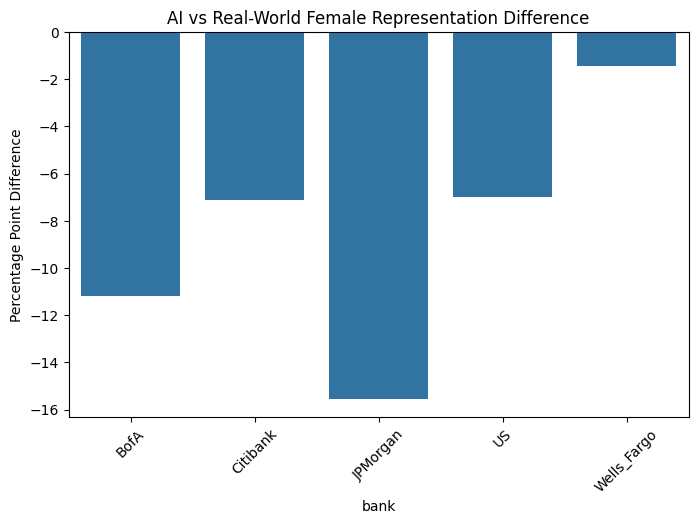

In [10]:
plt.figure(figsize=(8,5))
sns.barplot(data=result_df, x="bank", y="difference")

plt.axhline(0, linestyle="--")
plt.xticks(rotation=45)
plt.title("AI vs Real-World Female Representation Difference")
plt.ylabel("Percentage Point Difference")

plt.show()


In [11]:
rows = []

for model in labels['model'].unique():
    for bank in labels['bank'].unique():
        
        subset = labels[(labels['model'] == model) & 
                        (labels['bank'] == bank)]
        
        total_female = subset[subset['label'] == 1].shape[0]
        total_male = subset[subset['label'] == 0].shape[0]
        n = total_female + total_male
        
        if n == 0:
            continue
        
        p_ai = total_female / n
        bias_score = p_ai * 100
        
        difference = bias_score - representation
        
        # Standard error
        se = np.sqrt(p_ai * (1 - p_ai) / n) * 100
        
        # 95% CI
        ci_lower = difference - 1.96 * se
        ci_upper = difference + 1.96 * se
        
        significant = not (ci_lower <= 0 <= ci_upper)
        
        rows.append([
            model,
            bank,
            total_female,
            total_male,
            bias_score,
            representation,
            difference,
            se,
            ci_lower,
            ci_upper,
            significant
        ])

result_df_models = pd.DataFrame(rows, columns=[
    'model',
    'bank',
    'female_count',
    'male_count',
    'bias_score',
    'representation',
    'difference',
    'std_error',
    'ci_lower',
    'ci_upper',
    'significant'
])

print(result_df_models)

               model         bank  female_count  male_count  bias_score  \
0              dalle         BofA             6          14   30.000000   
1              dalle     Citibank             6          15   28.571429   
2              dalle     JPMorgan             4          17   19.047619   
3              dalle           US             6          16   27.272727   
4              dalle  Wells_Fargo             7          14   33.333333   
5         midjourney         BofA             1          19    5.000000   
6         midjourney     Citibank             1          16    5.882353   
7         midjourney     JPMorgan             2          27    6.896552   
8         midjourney           US             2          11   15.384615   
9         midjourney  Wells_Fargo             5          17   22.727273   
10  stable_diffusion         BofA             5          10   33.333333   
11  stable_diffusion     Citibank             8          12   40.000000   
12  stable_diffusion     

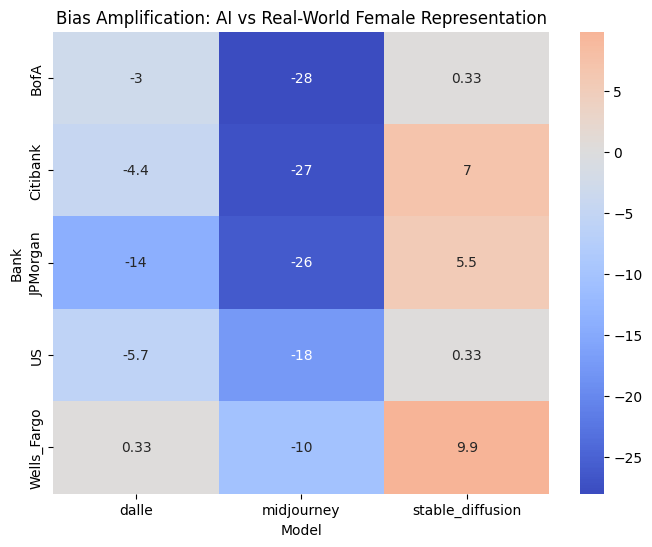

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = result_df_models.pivot(
    index="bank",
    columns="model",
    values="difference"
)

plt.figure(figsize=(8,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Bias Amplification: AI vs Real-World Female Representation")
plt.ylabel("Bank")
plt.xlabel("Model")

plt.show()
